# Uncertainty analysis

Monte Carlo: every parameter of the sheet is drawn from its distribution (typical value, min, max; `distribution` column), the RAW case, its scaled-up variant and its baselines are evaluated for each draw, and the same draws are used for both backgrounds (paired). If background samples exist (`data/background/unit_burden_samples_<scenario>.npz`, from ecoinvent's uncertainty data), each draw also uses one Monte Carlo iteration of the background burdens.

Number of draws, seed and the interval percentiles are set on the sheet (`study_setup`). Charts show typical-value bars and dots as in `03_results`, with the interval of the net impact as a line.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # repo root, so that `raw_lca` can be imported
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from raw_lca import Background, Model, load_inputs, run_products, spec_variable
from raw_lca.paths import BACKGROUND, RESULTS, newest_snapshot
from raw_lca.plots import plot_today_vs_2050

SNAPSHOT = newest_snapshot()
inp = load_inputs(SNAPSHOT)                          # validates the sheet snapshot, stops on errors
print("sheet snapshot:", SNAPSHOT.name)

# the two backgrounds shown in the charts: the scenarios flagged in_results on the sheet (first = today)
scn = inp.scenarios[inp.scenarios["in_results"].astype(str).str.upper() == "TRUE"]
(id_a, label_a), (id_b, label_b) = list(zip(scn["scenario_id"], scn["label"]))[:2]
models = {id_a: Model(inp, Background(BACKGROUND, id_a)), id_b: Model(inp, Background(BACKGROUND, id_b))}
(RESULTS / "figures").mkdir(parents=True, exist_ok=True); (RESULTS / "tables").mkdir(parents=True, exist_ok=True)

from raw_lca.uncertainty import run_uncertainty
n, seed = int(inp.setup["mc_iterations"]), int(inp.setup["mc_seed"])
pct = tuple(float(p) for p in str(inp.setup["interval_percentiles"]).split(";"))
print(f"{n} draws, seed {seed}, interval {pct[0]}-{pct[1]} %, background samples: "
      + ", ".join(f"{s}: {m.bg.n_samples or 'none'}" for s, m in models.items()))

sheet snapshot: 2026-09-25
2000 draws, seed 42, interval 5.0-95.0 %, background samples: baseline: 500, image_SSP2-L_2050: 500


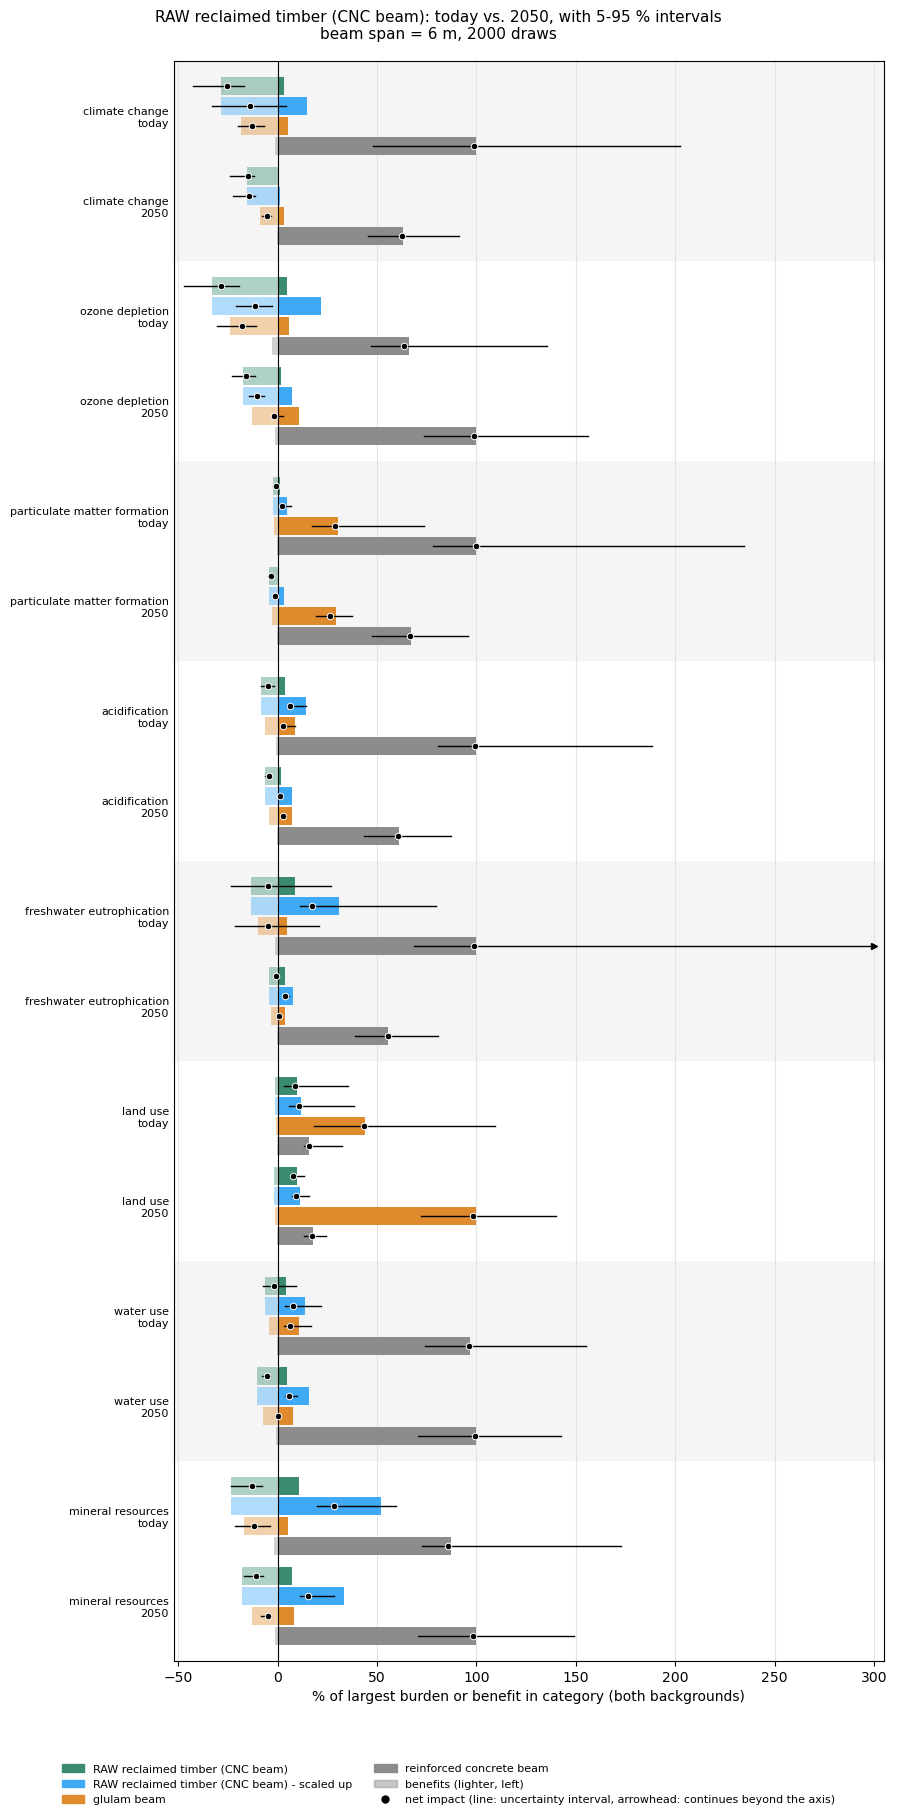

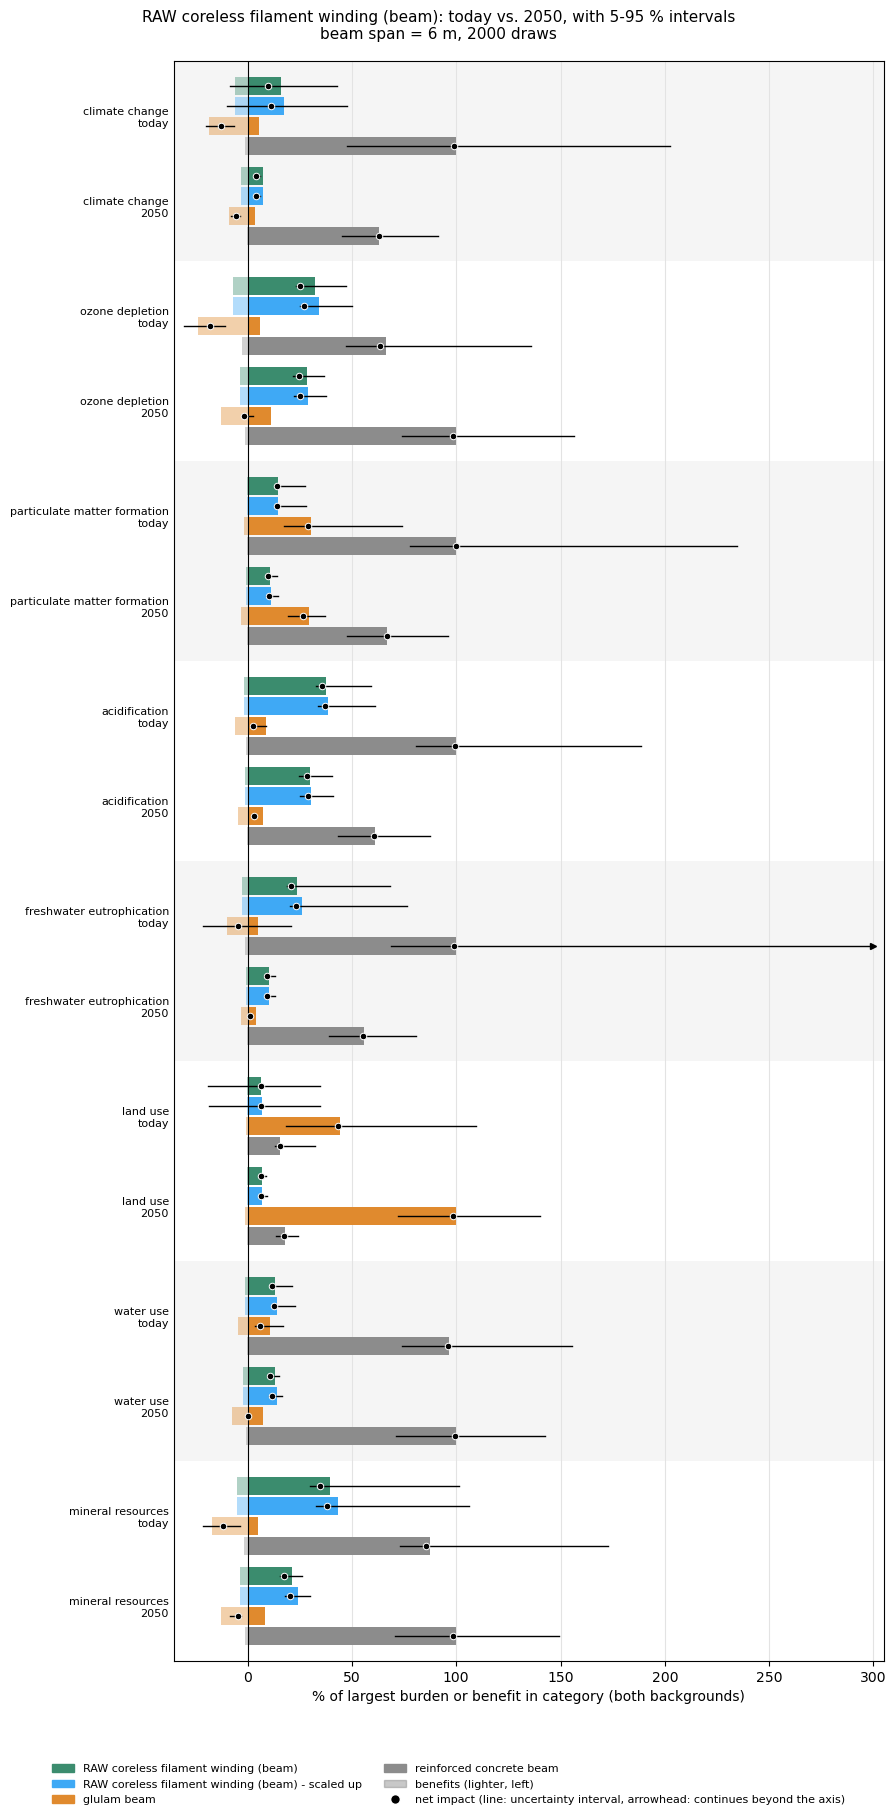

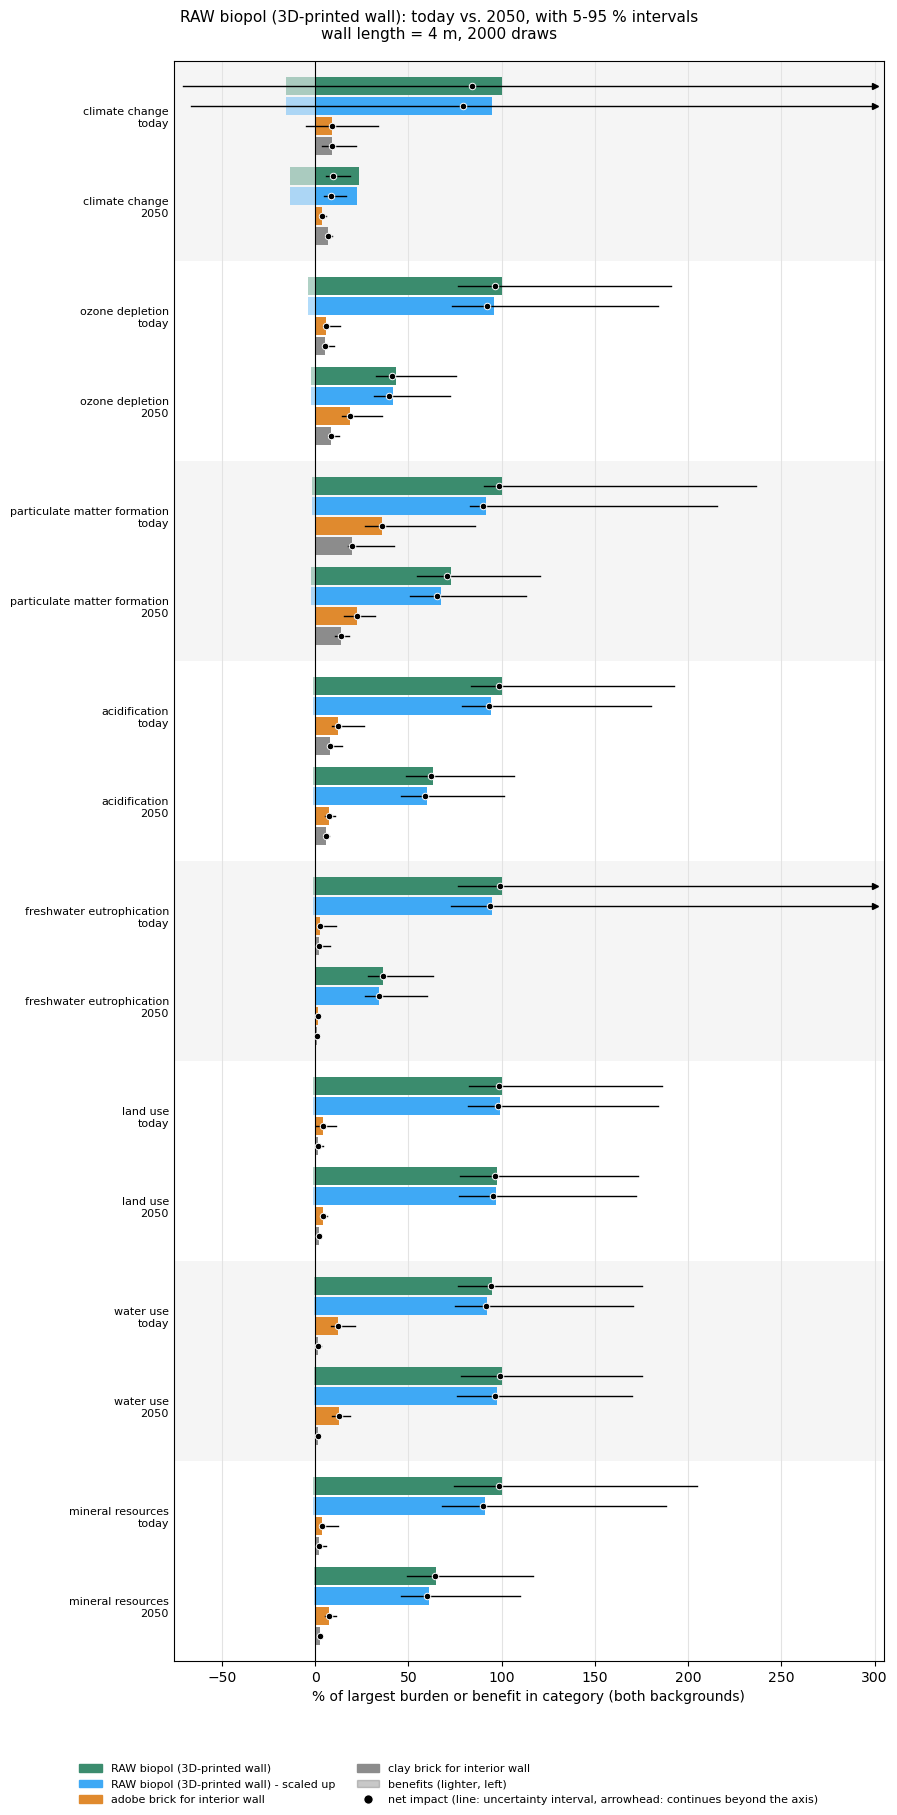

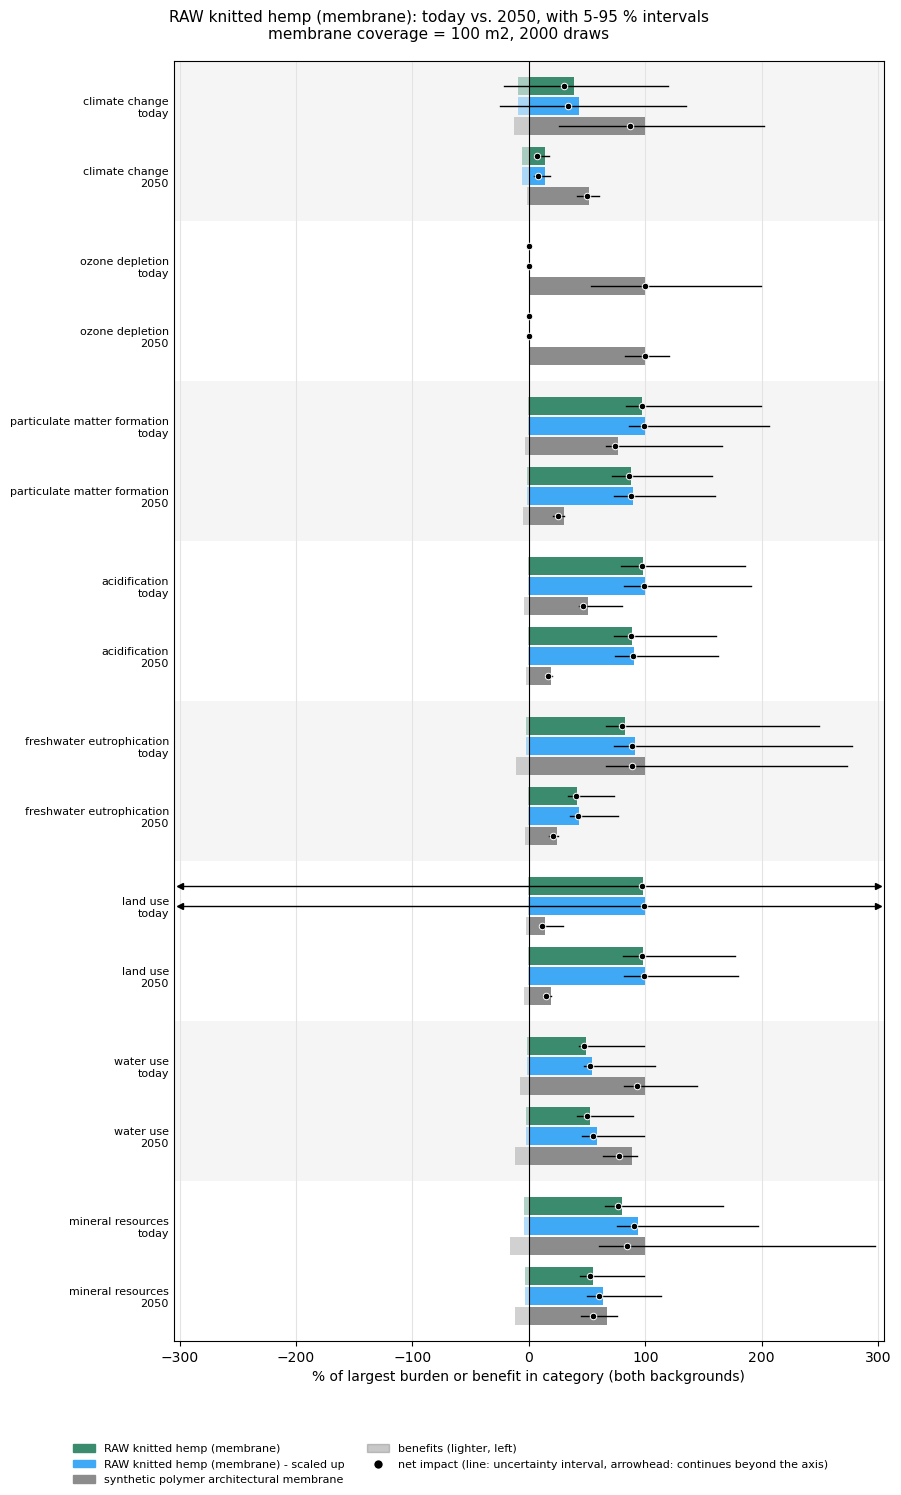

,raw_case,background,product,category,median,lo,hi,P(lower than glulam beam),P(lower than reinforced concrete beam),P(lower than adobe brick for interior wall),P(lower than clay brick for interior wall),P(lower than synthetic polymer architectural membrane)
0,raw_timber,today,RAW reclaimed timber (CNC beam),climate change,-97.11,-151.84,-60.37,0.99,1.0,NaN,NaN,NaN
8,raw_timber,today,RAW reclaimed timber (CNC beam) - scaled up,climate change,-48.12,-117.04,15.35,NaN,NaN,NaN,NaN,NaN
16,raw_timber,today,glulam beam,climate change,-44.12,-71.20,-23.81,NaN,NaN,NaN,NaN,NaN
24,raw_timber,today,reinforced concrete beam,climate change,397.71,170.29,721.13,NaN,NaN,NaN,NaN,NaN
32,raw_timber,2050,RAW reclaimed timber (CNC beam),climate change,-58.68,-85.04,-41.78,1.00,1.0,NaN,NaN,NaN
40,raw_timber,2050,RAW reclaimed timber (CNC beam) - scaled up,climate change,-55.31,-80.46,-39.45,NaN,NaN,NaN,NaN,NaN
48,raw_timber,2050,glulam beam,climate change,-18.94,-28.40,-12.20,NaN,NaN,NaN,NaN,NaN
56,raw_timber,2050,reinforced concrete beam,climate change,227.25,161.33,325.70,NaN,NaN,NaN,NaN,NaN
64,raw_cfw,today,RAW coreless filament winding (beam),climate change,49.18,-30.83,152.82,0.04,1.0,NaN,NaN,NaN
72,raw_cfw,today,RAW coreless filament winding (beam) - scaled up,climate change,54.54,-34.59,169.17,NaN,NaN,NaN,NaN,NaN


In [2]:
from raw_lca.plots import chart_categories
ua_all, tables = {}, []
for case_id, display_name in inp.raw_cases().items():
    ua = run_uncertainty(inp, models, case_id, n, seed)
    ua_all[case_id] = ua
    row = inp.products[inp.products.case_name == case_id].iloc[0]
    res = {sid: run_products(models[sid], case_id) for sid in (id_a, id_b)}
    intervals = {(lab, l): ua[sid].interval(l, pct) for sid, lab in ((id_a, label_a), (id_b, label_b)) for l in ua[sid].net}
    fig = plot_today_vs_2050(inp, f"{display_name}: {label_a} vs. {label_b}, with {pct[0]:g}-{pct[1]:g} % intervals\n"
                                  f"{row.spec_label} = {inp.specs[row.spec_variable]:g} {row.spec_unit}, {n} draws",
                             res[id_a], label_a, res[id_b], label_b, intervals=intervals)
    fig.savefig(RESULTS / "figures" / f"bars_uncertainty_{case_id}.png", dpi=150); fig.savefig(RESULTS / "figures" / f"bars_uncertainty_{case_id}.pdf")
    plt.show()
    labels = list(ua[id_a].net)
    for sid, lab in ((id_a, label_a), (id_b, label_b)):
        for l in labels:
            lo, hi = ua[sid].interval(l, pct); med = ua[sid].median(l)
            for cat, clabel in chart_categories(inp):
                ci = ua[sid].categories.index(cat)
                tables.append(dict(raw_case=case_id, background=lab, product=l, category=cat, median=med[ci], lo=lo[ci], hi=hi[ci],
                                   **{f"P(lower than {o})": ua[sid].prob_lower(l, o)[ci] for o in labels if o != l and not o.endswith("scaled up") and l == labels[0]}))
pd.DataFrame(tables).to_csv(RESULTS / "tables" / "uncertainty_net.csv", index=False)
display(pd.DataFrame(tables).query("category == 'climate change'").round(2))